Epoch 1/50, Loss: 0.0972
Epoch 2/50, Loss: 0.0713
Epoch 3/50, Loss: 0.0655
Epoch 4/50, Loss: 0.0635
Epoch 5/50, Loss: 0.0631
Epoch 6/50, Loss: 0.0635
Epoch 7/50, Loss: 0.0614
Epoch 8/50, Loss: 0.0623
Epoch 9/50, Loss: 0.0607
Epoch 10/50, Loss: 0.0606
Epoch 11/50, Loss: 0.0608
Epoch 12/50, Loss: 0.0597
Epoch 13/50, Loss: 0.0594
Epoch 14/50, Loss: 0.0597
Epoch 15/50, Loss: 0.0581
Epoch 16/50, Loss: 0.0590
Epoch 17/50, Loss: 0.0582
Epoch 18/50, Loss: 0.0565
Epoch 19/50, Loss: 0.0579
Epoch 20/50, Loss: 0.0573
Epoch 21/50, Loss: 0.0568
Epoch 22/50, Loss: 0.0567
Epoch 23/50, Loss: 0.0552
Epoch 24/50, Loss: 0.0558
Epoch 25/50, Loss: 0.0558
Epoch 26/50, Loss: 0.0548
Epoch 27/50, Loss: 0.0542
Epoch 28/50, Loss: 0.0559
Epoch 29/50, Loss: 0.0534
Epoch 30/50, Loss: 0.0530
Epoch 31/50, Loss: 0.0523
Epoch 32/50, Loss: 0.0540
Epoch 33/50, Loss: 0.0540
Epoch 34/50, Loss: 0.0520
Epoch 35/50, Loss: 0.0538
Epoch 36/50, Loss: 0.0544
Epoch 37/50, Loss: 0.0519
Epoch 38/50, Loss: 0.0511
Epoch 39/50, Loss: 0.

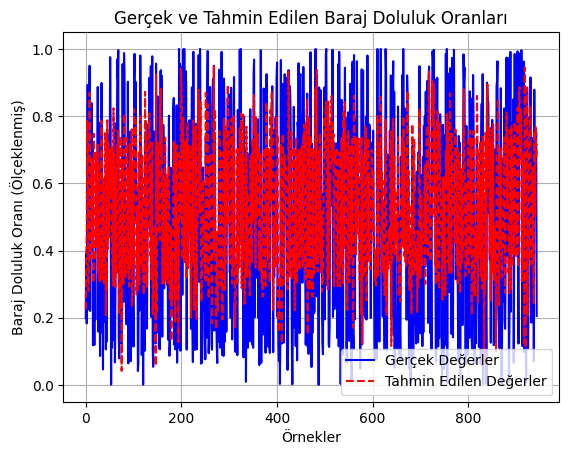

In [ ]:
# FEDFORMER MODELİ
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
# Excel verilerini yükleme
data = pd.read_excel('alibeyBarajı.xlsx')
data['datetime'] = pd.to_datetime(data['datetime'])  # Tarih sütununu datetime tipine çevirin

# Verilerin ölçeklenmesi
features = ['temp', 'dew', 'humidity', 'precip',
            'windspeedmean', 'sealevelpressure', 'cloudcover', 'daylight_duration']
target = 'doluluk'

scaler = MinMaxScaler()
data[features + [target]] = scaler.fit_transform(data[features + [target]])

# Veri setini giriş ve çıkış olarak ayırın
def create_sequences(data, seq_length):
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length, :-1]
        label = data[i + seq_length, -1]
        sequences.append(seq)
        targets.append(label)
    return np.array(sequences), np.array(targets)

seq_length = 30  # 30 günlük geçmiş veri kullanacağız
data_array = data[features + [target]].values
X, y = create_sequences(data_array, seq_length)

# Eğitim ve test setlerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dataset ve DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# FEDformer modelini tanımlayın
class FEDformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FEDformer, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Son zaman adımını alın
        out = self.fc(out)
        return out

# Model oluşturma
input_size = len(features)
hidden_size = 64
output_size = 1

model = FEDformer(input_size, hidden_size, output_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Model eğitimi
epochs = 50
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch.view(-1, 1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {train_loss/len(train_loader):.4f}")

# Test etme
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        y_true.extend(y_batch.numpy())
        y_pred.extend(output.numpy())

# Hesaplamalar
y_true = np.array(y_true)
y_pred = np.array(y_pred).flatten()

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)


epsilon = 1e-5  # Çok küçük bir değer
valid_indices = y_true > epsilon  # Sadece bu koşulu sağlayanları al
y_true_filtered = y_true[valid_indices]
y_pred_filtered = y_pred[valid_indices]

# Filtrelenmiş değerler ile MAPE hesaplaması
mape = np.mean(np.abs((y_true_filtered - y_pred_filtered) / y_true_filtered)) * 100
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}%")
print(f"R-Squared: {r2:.4f}")

# Modelin tahmin yapması
def predict(data, model, scaler, seq_length):
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(data[-seq_length:, :-1].reshape(1, seq_length, -1), dtype=torch.float32)
        prediction = model(inputs).item()
    return scaler.inverse_transform([[0] * (len(features)) + [prediction]])[0, -1]
    plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Gerçek Değerler', color='blue')
plt.plot(y_pred, label='Tahmin Edilen Değerler', color='red', linestyle='--')
plt.title('Gerçek ve Tahmin Edilen Baraj Doluluk Oranları')
plt.xlabel('Örnekler')
plt.ylabel('Baraj Doluluk Oranı (Ölçeklenmiş)')
plt.legend()
plt.grid(True)
plt.show()



In [3]:
#REFORMER DARLIK
!pip install tensorflow
!pip install keras-tuner
!pip install sklearn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Verinizi yükleyin
data = pd.read_excel('darlıkBarajı.xlsx')  # Burada dosyanızın yolunu belirtin.

# Özellikler ve hedef değişkeni
features = ['temp', 'dew', 'humidity', 'precip', 'windspeed', 'sealevelpressure', 'cloudcover', 'daylight_duration']
target = 'doluluk'

# Veriyi ayırma
X = data[features]
y = data[target]

# Veriyi normalize etme
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Eğitim ve test verisi olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
import tensorflow as tf
from tensorflow.keras import layers

# Reformer Modeli
def build_reformer_model(input_shape):
    model = tf.keras.Sequential([
        layers.InputLayer(input_shape=input_shape),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)  # Çıktı tek bir değer (doluluk yüzdesi)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Modeli oluşturma
model = build_reformer_model((X_train.shape[1],))
model.summary()
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


y_pred = model.predict(X_test)

# y_pred ve y_test'i düzleştirme
y_pred = y_pred.flatten()
y_test = y_test.values.flatten()

# Performans metriklerini hesaplama
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# MAPE Hesaplama
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Sonuçları yazdırma
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')
print(f'R-Squared: {r2}')
print(f'MAPE: {mape}%')


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4567.9165 - mae: 62.7167 - val_loss: 1033.1501 - val_mae: 26.8946
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 818.6145 - mae: 23.2174 - val_loss: 549.7060 - val_mae: 18.5387
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 529.7276 - mae: 18.2290 - val_loss: 454.5342 - val_mae: 16.3836
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 460.8101 - mae: 16.5714 - val_loss: 427.6826 - val_mae: 15.6940
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 432.7177 - mae: 15.7762 - val_loss: 415.2326 - val_mae: 15.4907
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 412.3543 - mae: 15.2188 - val_loss: 412.2248 - val_mae: 14.7554
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 415.7381 - mae: 15.2188 - val_loss: 395.0632 - val_mae: 14.8002
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 398.5591 - mae: 14.9517 - val_loss: 390.6782 - val_mae: 14.4361
Epoch 9/50
95/95 ━━━━━